In [1]:
import numpy as np
import matplotlib.pyplot as plt
from LIF_model import LIF
from LIF_layer import LIF_layer

In [2]:
dt = 1e-3
T = 1
time = np.arange(0, T, dt)

In [3]:
layer_1 = LIF_layer(2, 4, dt=dt)
layer_2 = LIF_layer(4, 1, dt=dt)

[[  9657.45099646   3126.48780753]
 [  5907.63692334  -5875.22592265]
 [  2577.87231353   4284.64825734]
 [-12416.03419936   8270.63378422]]
[[ -5912.18952866  11409.35325657 -23862.76692619  -3063.84766678]]


In [4]:
input_spike = [
    np.sort(np.random.rand(10)) for _ in range(2)]
print(input_spike)

[array([0.00329141, 0.00633843, 0.07924967, 0.16079854, 0.34873848,
       0.40966589, 0.55463765, 0.71867997, 0.90159174, 0.92911889]), array([0.28284648, 0.32221823, 0.33905849, 0.49534261, 0.50721213,
       0.53227319, 0.57823787, 0.78751804, 0.80959484, 0.92908526])]


In [5]:
output_spike_over_time = []

for t in time:

    current_spike = layer_1.forward(t, input_spike)
    spikes = layer_2.forward(t, current_spike)
    output_spike_over_time.append(spikes)

for i, neuron in enumerate(layer_1.neurons):
    print(f"Neurone {i} a spike à : {neuron.spikes}")

for i, neuron in enumerate(layer_2.neurons):
    print(f"Neurone {i} a spike à : {neuron.spikes}")

Neurone 0 a spike à : [np.float64(0.004), np.float64(0.005), np.float64(0.006), np.float64(0.007), np.float64(0.008), np.float64(0.009000000000000001), np.float64(0.01), np.float64(0.011), np.float64(0.012), np.float64(0.013000000000000001), np.float64(0.014), np.float64(0.015), np.float64(0.016), np.float64(0.017), np.float64(0.018000000000000002), np.float64(0.019), np.float64(0.021), np.float64(0.08), np.float64(0.081), np.float64(0.082), np.float64(0.083), np.float64(0.084), np.float64(0.085), np.float64(0.08600000000000001), np.float64(0.08700000000000001), np.float64(0.088), np.float64(0.089), np.float64(0.09), np.float64(0.091), np.float64(0.093), np.float64(0.161), np.float64(0.162), np.float64(0.163), np.float64(0.164), np.float64(0.165), np.float64(0.166), np.float64(0.167), np.float64(0.168), np.float64(0.169), np.float64(0.17), np.float64(0.171), np.float64(0.17200000000000001), np.float64(0.17400000000000002), np.float64(0.28300000000000003), np.float64(0.28400000000000003

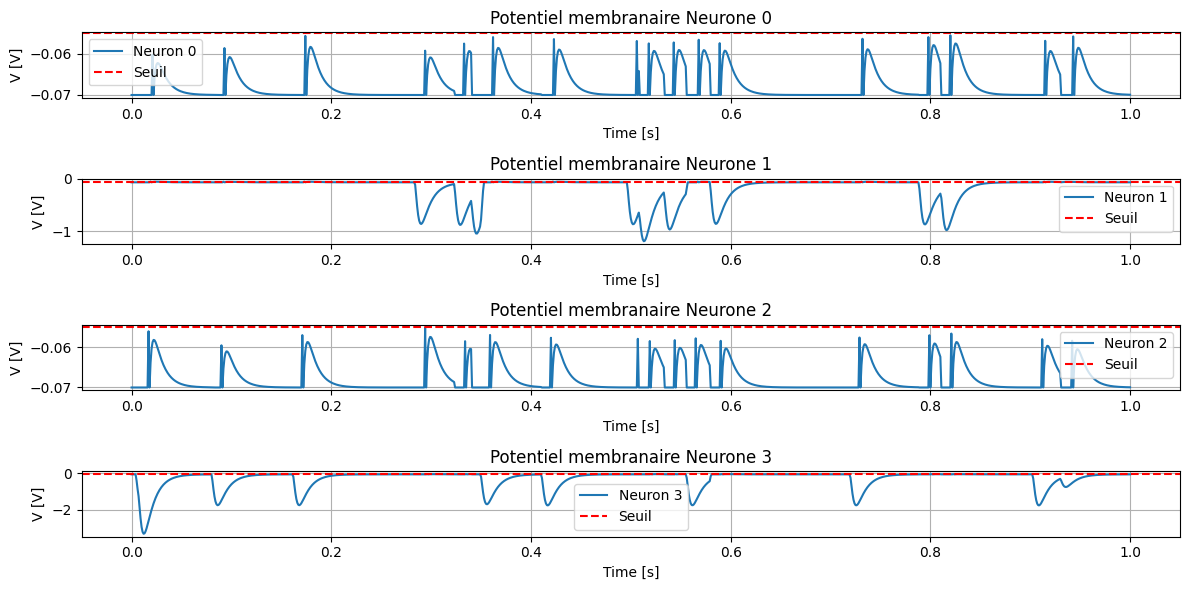

In [6]:
plt.figure(figsize=(12, 6))

for i, neuron in enumerate(layer_1.neurons):
    plt.subplot(4, 1, i+1)
    plt.plot(np.arange(len(neuron.V_trace))*dt, neuron.V_trace, label=f'Neuron {i}')
    plt.xlabel('Time [s]')
    plt.ylabel('V [V]')
    plt.title(f'Potentiel membranaire Neurone {i}')
    plt.axhline(y=neuron.V_th, color='r', linestyle='--', label='Seuil')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

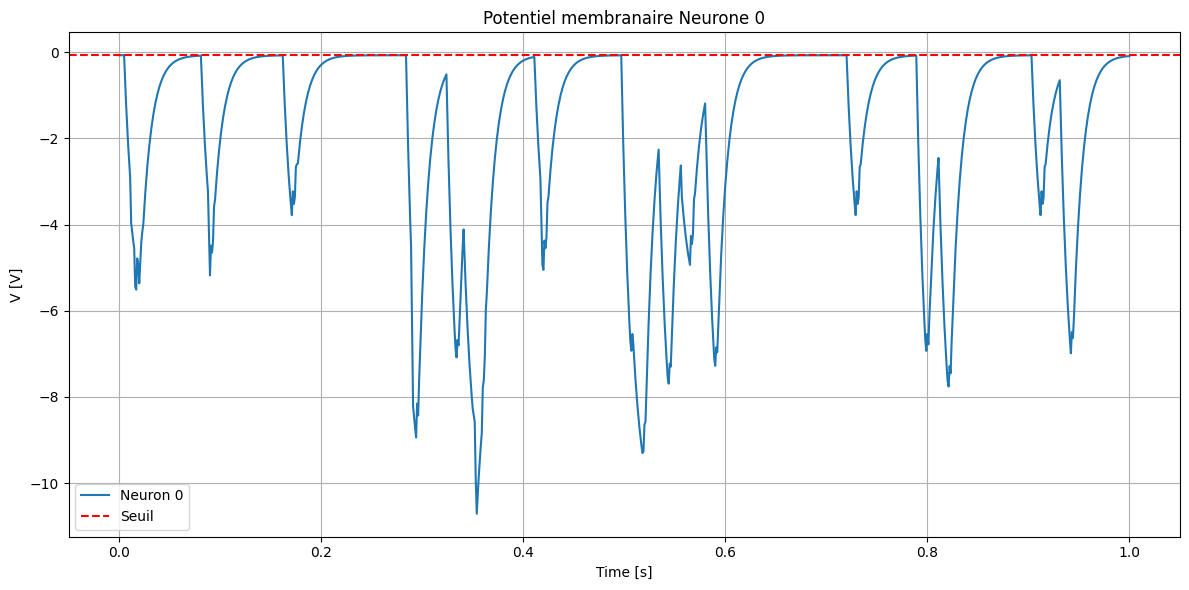

In [7]:
plt.figure(figsize=(12, 6))

for i, neuron in enumerate(layer_2.neurons):
    plt.subplot(1, 1, i+1)
    plt.plot(np.arange(len(neuron.V_trace))*dt, neuron.V_trace, label=f'Neuron {i}')
    plt.xlabel('Time [s]')
    plt.ylabel('V [V]')
    plt.title(f'Potentiel membranaire Neurone {i}')
    plt.axhline(y=neuron.V_th, color='r', linestyle='--', label='Seuil')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

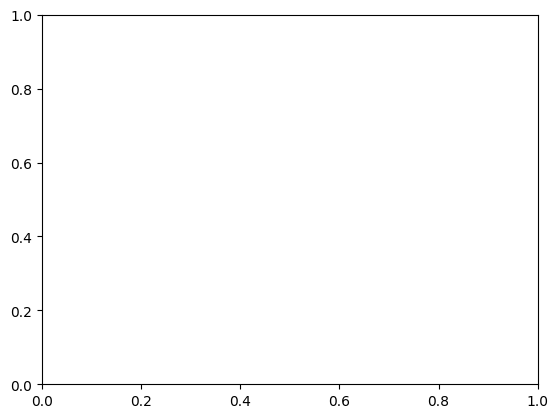

In [8]:
plt.eventplot(layer_2.neurons[0].spikes, lineoffsets=1, colors='black')
plt.show()